In [4]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Data load

In [5]:
embs = pd.read_parquet("../../data/playlist/embeddings_pure_bolt.parquet")
tracks = pd.read_parquet("../../data/playlist/track_lookup.parquet", columns=["track_rowid", "track_name", "track_popularity", "artist_name", "album_name", "label", "release_date"])
df = tracks.merge(embs, on="track_rowid", how="inner")
del embs, tracks

df

,track_rowid,track_name,track_popularity,artist_name,album_name,label,release_date,e0,e1,e2,...,e118,e119,e120,e121,e122,e123,e124,e125,e126,e127
0,1,The Giver,89,Chappell Roan,The Giver,Chappell Roan PS/ Island,2025-03-13,0.036216,0.011944,-0.209500,...,-0.208362,0.368888,0.248498,-0.293111,0.092885,-0.273926,0.206350,0.074494,-0.144147,0.180991
1,2,Another Life,43,NOTD,Digital Notes,Universal Music AB,2025-03-14,-0.163476,0.148268,-0.446109,...,-0.196914,0.312557,0.266789,0.099505,0.058830,-0.240161,0.055187,0.055483,0.083572,-0.155353
2,3,Lover Online,43,NOTD,Digital Notes,Universal Music AB,2025-03-14,-0.159618,0.132694,-0.444041,...,-0.041046,0.378840,0.212466,0.201121,-0.047752,-0.092247,0.042131,-0.049926,0.082891,-0.183175
3,4,Crash,56,NOTD,Digital Notes,Universal Music AB,2025-03-14,-0.222097,0.075386,-0.629530,...,-0.108012,0.492578,0.206480,0.147059,-0.185124,-0.239156,0.158749,0.039845,0.067549,-0.325725
4,5,I Just Missed A Call,51,NOTD,Digital Notes,Universal Music AB,2025-03-14,-0.022157,0.195753,-0.556658,...,-0.094603,0.617007,0.441123,0.130798,-0.037468,-0.288760,0.070787,-0.015783,0.116695,-0.321839
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5412044,247827222,Pequena Eva,0,Gabby B,Pequena Eva,Muy Bueno,2025-11-07,-0.218185,-0.213770,-0.237498,...,-0.282249,0.222295,0.199448,-0.269301,-0.100577,-0.182650,-0.174116,0.071979,-0.239299,-0.272316
5412045,247831685,Reinaldo,0,Allana Macedo,Reinaldo,AM PRODUCOES,2025-11-07,-0.265331,-0.189374,-0.250747,...,-0.286069,0.146482,0.188149,-0.256369,-0.164195,-0.112468,-0.185224,0.183731,-0.202297,-0.292355
5412046,248136901,APRCOYE,0,Anyoca,APRCOYE,Kasterwey Music,2025-11-06,0.148702,-0.252038,-0.181038,...,0.161273,0.200828,0.250193,-0.311748,-0.056369,0.208626,-0.204549,0.002240,-0.233303,0.177959
5412047,248198486,Más allá,0,Alcover,Más allá,"WE LOUD ENTERTAINMENT, LLC",2025-11-07,0.127353,-0.197649,-0.283100,...,0.089543,0.252793,0.217592,-0.183756,0.267667,0.173088,-0.197474,0.112230,-0.179609,-0.021674


# Full scale dataset

In [6]:
emb_cols = [c for c in df.columns if c.startswith("e")]
track_cols = [c for c in df.columns if c not in emb_cols]

## Embedding moduli

In [7]:
moduli = (df.sample(n = 10_000)[emb_cols] ** 2).sum(axis=1)
moduli

310773      7.460557
234530      8.579314
2590719     7.298811
3700694    11.793996
2366384     7.871448
             ...    
2644110     6.826230
2051623    10.283075
3303520     7.982317
516078     12.950955
1392654     6.037306
Length: 10000, dtype: float32

In [8]:
moduli.describe()

count    10000.000000
mean         9.422509
std          2.604524
min          2.965149
25%          7.645463
50%          9.072202
75%         10.747834
max         39.246952
dtype: float64

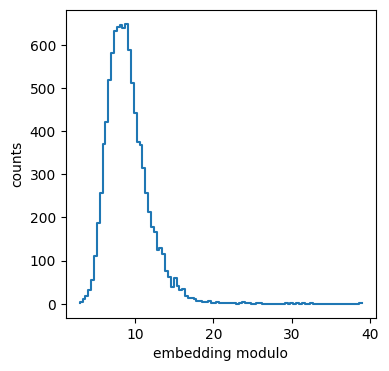

In [9]:
counts, bins = np.histogram(moduli, bins=100)
plt.figure(figsize=(4,4)); plt.step(bins[:-1], counts); plt.xlabel("embedding modulo"); plt.ylabel("counts"); plt.show()

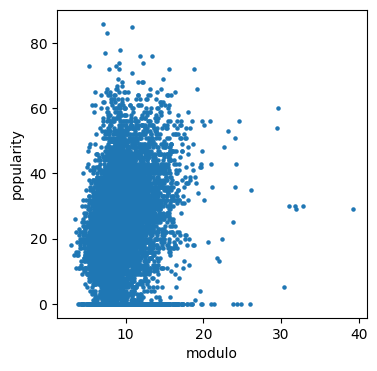

In [10]:
plt.figure(figsize=(4,4))
plt.scatter(
    moduli,
    df.loc[moduli.index]["track_popularity"],
    s = 5,
)
plt.xlabel("modulo"); plt.ylabel("popularity"); plt.show()

In [11]:
df[track_cols].loc[moduli.sort_values(ascending=False).index[:5]] 

,track_rowid,track_name,track_popularity,artist_name,album_name,label,release_date
1260137,33965131,Chaturanga,29,Unreaa,Chaturanga,Dynasty Music,2023-01-19
5115764,167846974,Raw Lyrics,30,Novando,Rok Nova,Independent,2024-03-10
4025542,125796280,Roots Revival,29,JAY BILL,Wait for Me,Independent,2024-08-29
4745795,141518282,Nina,30,PEPO TIGER,Fenta,Independent,2023-11-03
4918416,150101415,Neon Nostalgia,30,TESI23,Smoke,TESI23,2024-07-01


# Filtered dataset

For the next operations the dataset is too large for working on my home pc. We filter it.

In [12]:
df = df[df["track_popularity"] > 30].reset_index(drop=True)

In [13]:
df

,track_rowid,track_name,track_popularity,artist_name,album_name,label,release_date,e0,e1,e2,...,e118,e119,e120,e121,e122,e123,e124,e125,e126,e127
0,1,The Giver,89,Chappell Roan,The Giver,Chappell Roan PS/ Island,2025-03-13,0.036216,0.011944,-0.209500,...,-0.208362,0.368888,0.248498,-0.293111,0.092885,-0.273926,0.206350,0.074494,-0.144147,0.180991
1,2,Another Life,43,NOTD,Digital Notes,Universal Music AB,2025-03-14,-0.163476,0.148268,-0.446109,...,-0.196914,0.312557,0.266789,0.099505,0.058830,-0.240161,0.055187,0.055483,0.083572,-0.155353
2,3,Lover Online,43,NOTD,Digital Notes,Universal Music AB,2025-03-14,-0.159618,0.132694,-0.444041,...,-0.041046,0.378840,0.212466,0.201121,-0.047752,-0.092247,0.042131,-0.049926,0.082891,-0.183175
3,4,Crash,56,NOTD,Digital Notes,Universal Music AB,2025-03-14,-0.222097,0.075386,-0.629530,...,-0.108012,0.492578,0.206480,0.147059,-0.185124,-0.239156,0.158749,0.039845,0.067549,-0.325725
4,5,I Just Missed A Call,51,NOTD,Digital Notes,Universal Music AB,2025-03-14,-0.022157,0.195753,-0.556658,...,-0.094603,0.617007,0.441123,0.130798,-0.037468,-0.288760,0.070787,-0.015783,0.116695,-0.321839
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1478086,235991741,Senta Poca,32,Kadu Martins,Senta Poca,JNK Records,2025-10-21,-0.221146,-0.217576,-0.295460,...,-0.331078,0.271996,0.192200,-0.313651,-0.070902,-0.141083,-0.193133,-0.184256,-0.212529,-0.329982
1478087,236065089,Desatento,31,Mari & Rayane,É Na Pegada Darminina - Pt.2,Mari & Rayane,2025-10-17,-0.208841,-0.181255,-0.234591,...,-0.251974,0.194054,0.189883,-0.267390,-0.059279,-0.142265,-0.177896,0.083075,-0.229462,-0.231571
1478088,239230939,Por Quê - Ao Vivo,31,Natanzinho Lima,De Bar em Bar 8 (Ao Vivo),Natanzinho Lima,2025-10-24,-0.226984,-0.138304,-0.249505,...,-0.261020,0.200717,0.191363,-0.274765,-0.092903,-0.146083,-0.187004,0.144065,-0.235213,-0.261142
1478089,240713106,February 3rd,39,Iggoor,February 3rd,CWX Records,2025-08-14,-0.266689,-0.096414,-0.276619,...,-0.333963,0.178671,0.224742,-0.271873,-0.165313,-0.058321,-0.270387,0.071844,-0.228393,-0.237355


# Similiarities

In [45]:
import torch


lookup = df[track_cols]
embs = torch.tensor(df[emb_cols].to_numpy())
norm_embs = embs / embs.norm(dim=1, keepdim=True)
emb_norms_sq = embs.pow(2).sum(dim=1)   # precomputed once for L2 expanded formula


def similiar_cosine(
    query: str,
    artist: str | None = None,
    k: int = 10,
    diverse: bool = True,
    opposite: bool = False,
) -> pd.DataFrame:
    matches = lookup[lookup["track_name"].str.contains(query, case=False, na=False)]
    if artist is not None:
        matches = matches[matches["artist_name"].str.contains(artist, case=False, na=False)]
    if matches.empty:
        desc = f"'{query}'" + (f" by '{artist}'" if artist else "")
        print(f"No tracks matching {desc}")
        return pd.DataFrame()

    row = matches.sort_values("track_popularity", ascending=False).iloc[0]
    print(f"Query: {row['track_name']} — {row['artist_name']}  (pop {row['track_popularity']})")
    tid = row.name

    fetch = k * 50 + 1
    sims = norm_embs[tid] @ norm_embs.T          # (u·v) / (‖u‖‖v‖)
    top_vals, top_idx = torch.topk(sims, min(fetch, len(sims)), largest=not opposite)

    candidates = lookup.iloc[top_idx.tolist()].copy()
    candidates["similarity"] = top_vals.numpy()  # topk already sorted descending
    if diverse:
        candidates = candidates.drop_duplicates(subset="artist_name")
    return candidates.head(k)[["track_name", "artist_name", "track_popularity", "similarity"]]


def similiar_l2(
    query: str,
    artist: str | None = None,
    k: int = 10,
    diverse: bool = True,
    opposite: bool = False,
) -> pd.DataFrame:
    matches = lookup[lookup["track_name"].str.contains(query, case=False, na=False)]
    if artist is not None:
        matches = matches[matches["artist_name"].str.contains(artist, case=False, na=False)]
    if matches.empty:
        desc = f"'{query}'" + (f" by '{artist}'" if artist else "")
        print(f"No tracks matching {desc}")
        return pd.DataFrame()

    row = matches.sort_values("track_popularity", ascending=False).iloc[0]
    print(f"Query: {row['track_name']} — {row['artist_name']}  (pop {row['track_popularity']})")
    tid = row.name

    fetch = k * 50 + 1
    sims = emb_norms_sq[tid] + emb_norms_sq - 2 * (embs[tid] @ embs.T)
    top_vals, top_idx = torch.topk(sims, min(fetch, len(sims)), largest=opposite)

    candidates = lookup.iloc[top_idx.tolist()].copy()
    candidates["similarity"] = top_vals.numpy()  # topk already sorted ascending
    if diverse:
        candidates = candidates.drop_duplicates(subset="artist_name")
    return candidates.head(k)[["track_name", "artist_name", "track_popularity", "similarity"]]


In [46]:
queries = [
    ("dunkelheit",),
]

In [47]:
for track, *artist in queries:
    display(similiar_l2(
        query=track, artist=artist[0] if artist else None
    ))
    display(similiar_cosine(
        query=track, artist=artist[0] if artist else None
    ))

Query: Dunkelheit — Burzum  (pop 54)


,track_name,artist_name,track_popularity,similarity
1112842,Dunkelheit,Burzum,54,9.536743e-07
1023169,Freezing Moon,Mayhem,55,1.710282e+00
990381,A Fine Day to Die,Bathory,48,2.156164e+00
1023189,Transilvanian Hunger - Studio,Darkthrone,46,2.275140e+00
1280771,A Dying God Coming into Human Flesh,Celtic Frost,41,3.069511e+00
1334363,Myspys,Lifelover,46,3.117375e+00
991497,Messiah,Hellhammer,36,3.161346e+00
1006562,"My Dark Subconscious (""December Moon"" Demo 1986)",Morbid,36,3.281317e+00
1172267,Where Dead Angels Lie,Dissection,46,3.416249e+00
981671,Furrows of Gods - Борозни Богів,Drudkh,33,3.451766e+00


Query: Dunkelheit — Burzum  (pop 54)


,track_name,artist_name,track_popularity,similarity
1112842,Dunkelheit,Burzum,54,1.000000
1023169,Freezing Moon,Mayhem,55,0.887209
1023189,Transilvanian Hunger - Studio,Darkthrone,46,0.872966
990381,A Fine Day to Die,Bathory,48,0.872143
991497,Messiah,Hellhammer,36,0.823924
1334413,Berzerker,Ancient North,34,0.819075
1172267,Where Dead Angels Lie,Dissection,46,0.815678
1334363,Myspys,Lifelover,46,0.814891
1280771,A Dying God Coming into Human Flesh,Celtic Frost,41,0.808380
1006562,"My Dark Subconscious (""December Moon"" Demo 1986)",Morbid,36,0.806587


In [50]:
for track, *artist in queries:
    display(similiar_cosine(
        query=track, artist=artist[0] if artist else None,
        opposite=True
    ))
    display(similiar_l2(
        query=track, artist=artist[0] if artist else None,
        opposite=True,
    ))

Query: Dunkelheit — Burzum  (pop 54)


,track_name,artist_name,track_popularity,similarity
819734,Little Mo' Betta,David Davis,32,-0.128778
1371259,"Somehow, Someway",Chad Price,32,-0.127242
676382,Make It Happen,John Splithoff,37,-0.121990
697515,Let Me Love You,N2N,33,-0.120475
1374695,How Will I Know,Guestlist.,32,-0.118643
1202518,C'est la vie,Maurice Moore,34,-0.118067
384736,Smart Love,Drax Project,31,-0.113644
1217043,Drunk Words,Mitchy & André,34,-0.112677
241283,Won't Ever Say Goodbye,The Shadowboxers,31,-0.111649
540267,Sunday Morning,Little Giants,31,-0.111265


Query: Dunkelheit — Burzum  (pop 54)


,track_name,artist_name,track_popularity,similarity
1088487,let's forget what we could be,Celicia Rose,39,87.816170
885562,Chitaury,J Rodis,41,77.562218
1335047,Better Off,Yuki Shinoda,37,72.743080
1222599,Black T,Coco Laced,43,69.133179
1468126,Regret It,Ashwin Gane,41,63.393196
1274650,Winter Ahead (with PARK HYO SHIN),V,79,63.042072
131033,Who,Jimin,84,54.301418
1468990,Espejo,Ana J,38,52.805859
1109192,Electric Wind,Amado la R,46,49.728043
1466713,TAS COMO LOCO - Remix,Alayón,34,45.605629


In [49]:
def cosine_distance(
    query_a: str,
    query_b: str,
    artist_a: str | None = None,
    artist_b: str | None = None,
) -> float:
    def resolve(query, artist):
        matches = lookup[lookup["track_name"].str.contains(query, case=False, na=False)]
        if artist is not None:
            matches = matches[matches["artist_name"].str.contains(artist, case=False, na=False)]
        if matches.empty:
            raise ValueError(f"No tracks matching '{query}'" + (f" by '{artist}'" if artist else ""))
        row = matches.sort_values("track_popularity", ascending=False).iloc[0]
        print(f"  {row['track_name']} — {row['artist_name']}  (pop {row['track_popularity']})")
        return row.name

    print("Track A:", end=" "); tid_a = resolve(query_a, artist_a)
    print("Track B:", end=" "); tid_b = resolve(query_b, artist_b)
    sim = float(norm_embs[tid_a] @ norm_embs[tid_b])
    print(f"Cosine similarity: {sim:.4f}")
    return sim


sim_metal  = cosine_distance("dunkelheit", "raining blood")
print()
sim_pop    = cosine_distance("dunkelheit", "monster", artist_b="skillet")
print()
sim_pop    = cosine_distance("dunkelheit", "harder", artist_b="public enemy")
print()

Track A:   Dunkelheit — Burzum  (pop 54)
Track B:   Raining Blood — Slayer  (pop 70)
Cosine similarity: 0.6943

Track A:   Dunkelheit — Burzum  (pop 54)
Track B:   Monster — Skillet  (pop 81)
Cosine similarity: 0.3907

Track A:   Dunkelheit — Burzum  (pop 54)
Track B:   Harder Than You Think — Public Enemy  (pop 64)
Cosine similarity: 0.3264



# Artists

In [53]:
dfa = df.groupby("artist_name").size()

In [54]:
dfa

artist_name
 Superior              1
!!!                    8
!BEN                   2
!Dav1d                17
!MP4CT                 2
                      ..
２８１４                   8
Ｏｃｅａｎ Ｓｈｏｒｅｓ           1
ｇｓｌｆ                   1
･ ･－･ ･－ ･･･ ･ －･･     6
･－･ ･－ ･･･ ･ －･･       1
Length: 205141, dtype: int64